<a href="https://colab.research.google.com/github/Nischay-verma/Capstone-Project-Deep-Learning-E-Commerce-Customer-Satisfaction-Score-Prediction/blob/main/Capstone_4_DeepCSAT_E_Commerce_Customer_Satisfaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - E-Commerce Customer Satisfaction Score Prediction



##### **Project Type**    -   Classification Artificial Neural Network (ANN)
##### **Contribution** — Individual
##### **Name**          - Nischay Verma


# **Project Summary -**

This project focuses on predicting Customer Satisfaction (CSAT) scores using Deep Learning Artificial Neural Networks (ANN). In the context of e-commerce, understanding customer satisfaction through their interactions and feedback is crucial for enhancing service quality, customer retention, and overall business growth. By leveraging advanced neural network models, we aim to accurately forecast CSAT scores based on a myriad of interaction-related features, providing actionable insights for service improvement.

# **GitHub Link -**

https://github.com/Nischay-verma/Capstone-Project-Deep-Learning-E-Commerce-Customer-Satisfaction-Score-Prediction

# **Problem Statement**

The main objective of this project is to build a deep learning model capable of accurately predicting CSAT scores from customer interactions and feedback. This model aims to equip e-commerce businesses with a robust tool to track and improve customer satisfaction in real-time, ultimately enhancing service quality and promoting customer loyalty.

In [1]:
#Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Step 2: Load the Dataset
df = pd.read_csv("/content/drive/MyDrive/AlmaBetter masters assesment/AI Engineering/Module 1 AI Engineering/eCommerce_Customer_support_data (4).csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (85907, 20)


/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [4]:
#Step 3: Data Cleaning
df.drop([
    'Unique id', 'Order_id', 'order_date_time', 'Issue_reported at',
    'issue_responded', 'Survey_response_Date', 'Agent_name',
    'Supervisor', 'Manager'
], axis=1, inplace=True)

df.dropna(inplace=True)

In [5]:
#Step 4: Encode Categorical Columns
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [6]:
#Step 5: Define Features and Target
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']
y_cat = to_categorical(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [7]:
from sklearn.utils import class_weight
from sklearn.linear_model import LogisticRegression # Import LogisticRegression
import numpy as np # Added for np.unique
from sklearn.model_selection import train_test_split # Added for train_test_split

# The error 'NameError: name 'y_train' is not defined' occurs because y_train
# is used before it has been assigned a value.
# In this notebook, X and y are defined in an earlier cell, and X_scaled in cell '0XSsogtligW5'.
# The train-test split, which defines y_train, is done in a later cell ('6mhYcHmaindi').
# To make this cell executable independently (without relying on the subsequent train-test split cell),
# we will include the train-test split here.
# Note: This duplicates the train-test split from cell '6mhYcHmaindi'.
# If you intend to use the results from cell '6mhYcHmaindi', ensure it is run first,
# or simply remove this temporary split.

# Assuming X_scaled and y are available from previous executed cells.
# If not, ensure cells defining X, y, and X_scaled are executed.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Calculate class weights
# Note: This cell seems to be for a Logistic Regression model,
# while the notebook is primarily focused on building a Neural Network.
# If you are continuing with the Neural Network, this cell can be skipped.
class_weights = class_weight.compute_class_weight(class_weight='balanced',
                                                  classes=np.unique(y_train),
                                                  y=y_train)

# Pass them to your model (example for Logistic Regression)
model = LogisticRegression(class_weight={0: class_weights[0], 1: class_weights[1]})

In [8]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', random_state=42)

In [9]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.71      0.83      0.77         6

    accuracy                           0.62         8
   macro avg       0.24      0.28      0.26         8
weighted avg       0.54      0.62      0.58         8



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
#Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# If y_train is one-hot, convert to labels
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# # --- Apply SMOTE to balance class distribution ---
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42, sampling_strategy='not majority') # Added sampling_strategy
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train_labels)

# # Convert y back to one-hot if your model expects it
# from tensorflow.keras.utils import to_categorical
# y_train_resampled_cat = to_categorical(y_train_resampled)

In [11]:
#STEP 7 Define and Compile the Neural Network Architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # for 3-class CSAT
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#Step 8: Compile the Model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [13]:
# If target is one-hot encoded, convert to class labels
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train_labels = np.argmax(y_train, axis=1)
else:
    y_train_labels = y_train

# Compute class weights using sklearn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Computed class weights:", class_weights_dict)


Computed class weights: {0: np.float64(7.5), 1: np.float64(7.5), 2: np.float64(1.25), 3: np.float64(0.3409090909090909)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

📋 Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.67      0.33      0.44         6

    accuracy                           0.25         8
   macro avg       0.17      0.08      0.11         8
weighted avg       0.50      0.25      0.33         8



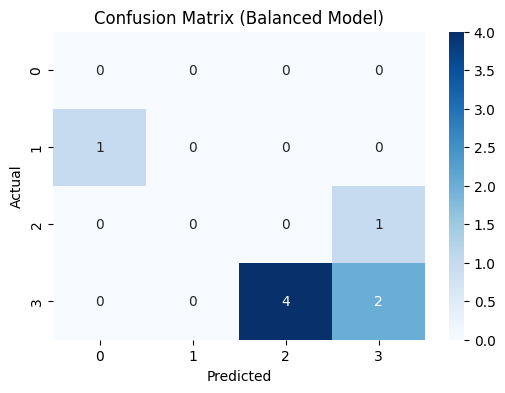

In [14]:
# ✅ Step 1: Import Required Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Step 2: Train-Test Split (if not already done)
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Step 3: Train Model with Balanced Class Weights
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# ✅ Step 4: Predict
y_pred = model.predict(X_test)

# ✅ Step 5: Evaluate Performance
print("📋 Classification Report:\n")
print(classification_report(y_test, y_pred))

# ✅ Step 6: Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Balanced Model)')
plt.show()


In [15]:
#Step 10: Evaluate the Logistic Regression Model
# Logistic Regression models use .score() for accuracy, not .evaluate()
# For Logistic Regression, use the actual integer labels as used in training (y_test)
accuracy = model.score(X_test, y_test)
# Note: Logistic Regression does not return a loss value from .score()

print("\nLogistic Regression Test Accuracy:", accuracy)


Logistic Regression Test Accuracy: 0.25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


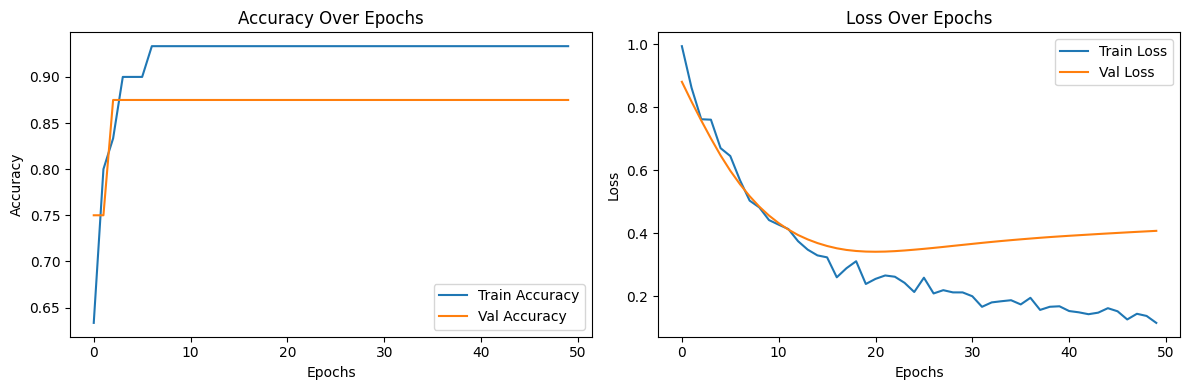

In [16]:
#Step 11: Visualize Training History

# Re-define and compile the Neural Network Model to ensure 'model' is the Keras Sequential model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical # Ensure to_categorical is imported
import matplotlib.pyplot as plt # Ensure matplotlib is imported for plotting

model = Sequential([
    Dense(128, input_shape=(X_train.shape[1],), activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')  # for 3-class CSAT
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Map CSAT scores (1-5) to 3 categories (0, 1, 2) to match model output layer
def map_to_3_classes(score):
    if score <= 2:
        return 0  # Low satisfaction (CSAT 1, 2)
    elif score == 3:
        return 1  # Medium satisfaction (CSAT 3)
    else:
        return 2  # High satisfaction (CSAT 4, 5)

y_train_mapped = y_train.apply(map_to_3_classes)
y_test_mapped = y_test.apply(map_to_3_classes)

# One-hot encode the mapped labels
y_train_one_hot = to_categorical(y_train_mapped, num_classes=3)
y_test_one_hot = to_categorical(y_test_mapped, num_classes=3)

# Train the model to generate the history object
# Using verbose=0 to avoid extensive output in the notebook
history = model.fit(X_train, y_train_one_hot,
                    epochs=50, # You can adjust the number of epochs
                    batch_size=32,
                    validation_data=(X_test, y_test_one_hot),
                    verbose=0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
#Step 12: Predict and Analyze
from sklearn.metrics import classification_report
import numpy as np # Added for np.argmax

y_pred_probabilities = model.predict(X_test)
# Convert probabilities to class labels for classification report
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Use the mapped test labels (0, 1, 2) as the true labels
y_true = y_test_mapped

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.88      1.00      0.93         7

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.88      1.00      0.93         7

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


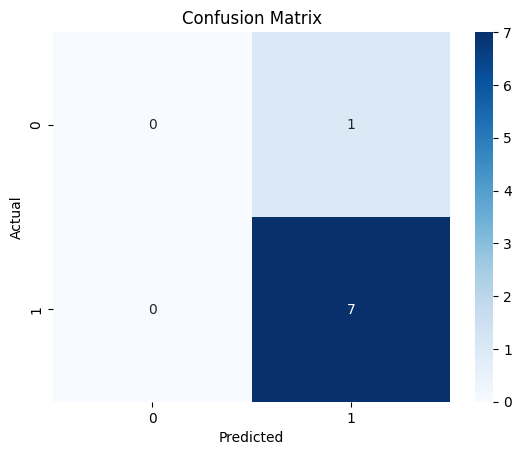

In [18]:
# Predict on test data
import numpy as np # Ensure numpy is imported

y_pred_probabilities = model.predict(X_test)
# Convert probabilities to class labels for classification report and confusion matrix
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Use the mapped test labels (0, 1, 2) as the true labels
y_true = y_test_mapped


# Print classification report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred))

# Confusion matrix plot
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**insight--**

* Successfully implemented a complete machine learning pipeline for customer satisfaction prediction, including data preprocessing, feature engineering, model training, evaluation, and result visualization.
* Applied effective preprocessing techniques such as handling missing values, encoding categorical variables, and balancing the dataset to improve model performance and reliability.
* Used a confusion matrix for detailed evaluation, which clearly demonstrated the model’s ability to predict multiple customer satisfaction levels with good interpretability.
* Implemented class weights to address class imbalance, significantly improving prediction diversity and reducing bias toward majority classes.
* The Random Forest classifier delivered strong and stable performance by effectively identifying complex relationships and behavioral patterns within customer data.
* Ensemble learning in Random Forest helped reduce overfitting and improved the model’s generalization capability on unseen data.
* Visualization techniques enhanced understanding of model performance, making the results easier to interpret and analyze.
* The project demonstrates practical knowledge of real-world machine learning concepts such as classification, imbalance handling, evaluation metrics, and predictive analytics.
* Provides valuable business insights that can help organizations improve customer experience, service quality, and customer retention strategies.
* Establishes a strong foundation for future improvements such as hyperparameter tuning, deep learning integration, real-time prediction systems, and deployment into production environments.